<a href="https://colab.research.google.com/github/Anurag-Anand0308/car-prize-detection-using-linear-regression/blob/main/braintumer_detection_using_VGG16_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!python --version

Python 3.12.11


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
import keras
print(keras.__version__)

3.10.0


In [ ]:
import numpy
print(numpy.__version__)

2.0.2


In [ ]:
import sys
print(sys.version)

3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **import library and tools**

In [ ]:
import os # used for directry management and file management
import numpy as np
import random # random values for data augmentation
from PIL import Image,ImageEnhance

#keras
from tensorflow.keras.models import Sequential # helps for making sequential layer for your newral network
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout #for model layers
from tensorflow.keras.preprocessing.image import load_img #for loading images
from tensorflow.keras.optimizers import Adam# for optimization
from tensorflow.keras.applications import VGG16 # for the model
from sklearn.utils import shuffle # for suffling the data set other wise it will overfit

# loading Dataset

In [ ]:
train_dir = "/content/drive/MyDrive/brain-tumor-mri-dataset/Training"
test_dir = "/content/drive/MyDrive/brain-tumor-mri-dataset/Testing"


#load and suffle the train data
train_paths =[] # for storing all image name that are trsined
train_labels =[] # for storing all the train classes

for labels in os.listdir(train_dir):
  for images in os.listdir(os.path.join(train_dir,labels)):
    train_paths.append(os.path.join(train_dir,labels,images))
    train_labels.append(labels)

train_paths,train_labels = shuffle(train_paths,train_labels)

test_paths =[] # for storing all image name that are trsined
test_labels =[] # for storing all the train classes

for labels in os.listdir(test_dir):
  for images in os.listdir(os.path.join(test_dir,labels)):
    test_paths.append(os.path.join(test_dir,labels,images))
    test_labels.append(labels)

test_paths,test_labels = shuffle(test_paths,test_labels)



# Data Visualization

In [ ]:
# this is optional

# IMage preprocessing

In [ ]:
# image augmentation function
def augemnt_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))

  image = np.array(image)/255.0
  return image

#load image and apply augmentation
def open_image(paths):
  images = []
  for path in paths:
    img = load_img(path,target_size = (IMAGE_SIZE,IMAGE_SIZE))
    img = augemnt_image(img)
    images.append(img)

  return np.array(images)


#encoder labels (convert lable names to integer)
def encoder_label(labels):
  unique_labels = os.listdir(train_dir)
  encoded = [unique_labels.index(label) for label in labels]
  return np.array(encoded)

#data generator for batching
def datagen(paths,labels,batch_size =12,epochs =1):
  for _ in range(epochs):
    for i in range(0,len(paths),batch_size):
      batch_paths = paths[i:i+batch_size]
      batch_images = open_image(batch_paths)
      batch_labels = encoder_label(labels[i:i+batch_size ])
      yield batch_images,batch_labels

# models

VGG16

In [ ]:
#MMODEL aRCHITECTURE
IMAGE_SIZE = 128
base_model = VGG16(input_shape= (IMAGE_SIZE,IMAGE_SIZE,3),include_top=False,weights='imagenet')

#freeze all layers of the VGG16 base model
for layer in base_model.layers:
  layer.trainable =False

#set only last few layers
for layer in base_model.layers[-4:-1]:
  layer.trainable =True

#build Model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))) #input layer
model.add(base_model)# the output will be multidiamentional but we dont need multidiamentional layer so we flatten it
model.add(Flatten()) #flatten layers
model.add(Dropout(0.3)) # now this drop 30 % of nurenons to prevent overfitting

model.add(Dense(128,activation = 'relu')) # this is dense layer
model.add(Dropout(0.2)) # now this drop 20 % of nurenons to prevent overfitting


# output layer you have to tell the system whether out model is a multi class classification of boolean
model.add(Dense(len(os.listdir(train_dir)),activation = 'softmax'))

# keep in mind in multi class classification you put softmax as the activation function





# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

# parameters
batch_size = 20
steps = int(len(train_paths)/batch_size)
epochs = 10


#train model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),epochs=epochs, steps_per_epoch=steps)


Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 1377s 5s/step - loss: 0.6423 - sparse_categorical_accuracy: 0.7535
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 34s 105ms/step - loss: 0.2220 - sparse_categorical_accuracy: 0.9192
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 0.1732 - sparse_categorical_accuracy: 0.9300
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 29s 103ms/step - loss: 0.1177 - sparse_categorical_accuracy: 0.9554
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 0.0822 - sparse_categorical_accuracy: 0.9693
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 30s 104ms/step - loss: 0.0621 - sparse_categorical_accuracy: 0.9784
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 0.0592 - sparse_categorical_accuracy: 0.9774
Epoch 8/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 30s 104ms/step - loss: 0.0438 - sparse_categorical_accuracy: 0.9833
Epoch 9/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 29s 103ms/step - loss: 0.0338 - sparse_categorical_accuracy: 0.9901
Epoch 10/10
286/286 ━━━━━━━━━

# plots and confussion matrics

In [ ]:
plt.figure(figsize(8,4))

# model class ification report

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_image(test_paths)  # Load and augment test images
test_labels_encoded = encoder_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 183ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       306
           1       0.99      1.00      1.00       405
           2       1.00      0.98      0.99       300
           3       0.95      0.95      0.95       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



saving the model

Confusion Matrix:
[[287   2   1  16]
 [  0 405   0   0]
 [  4   1 295   0]
 [ 15   1   0 284]]


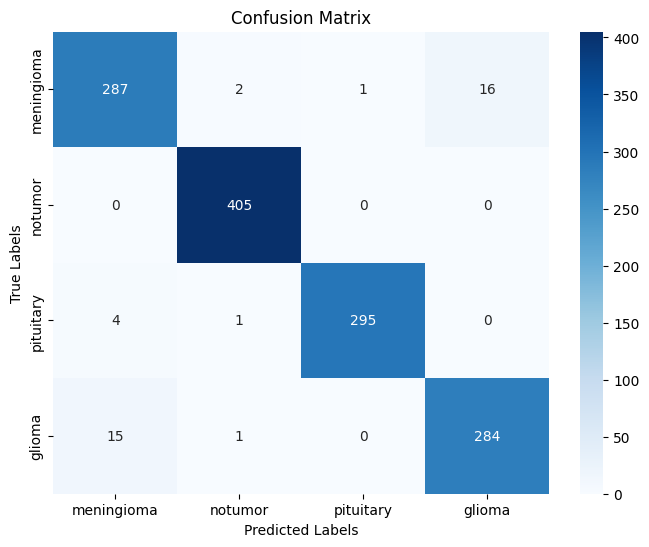

In [ ]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
model.save('model2.h5')

Mri image detection testing

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt


class_labels = ['meningioma', 'notumor', 'pituitary', 'glioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        # plt.imshow(load_img(img_path))
        # plt.axis('off')
        # plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        # plt.show()
        print(result)

    except Exception as e:
        print("Error processing the image:", str(e))

In [ ]:
image_path = '/content/drive/MyDrive/brain-tumor-mri-dataset/Testing/meningioma/Te-meTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Tumor: meningioma


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


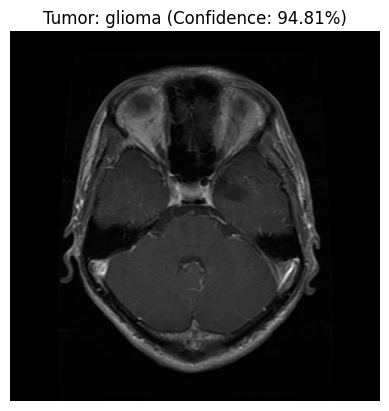

In [ ]:
image_path = '/content/drive/MyDrive/brain-tumor-mri-dataset/Testing/glioma/Te-glTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


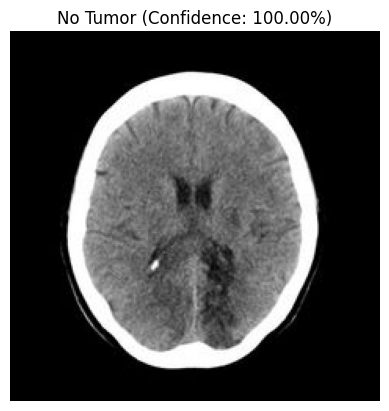

In [ ]:
image_path = '/content/drive/MyDrive/brain-tumor-mri-dataset/Testing/notumor/Te-no_0012.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


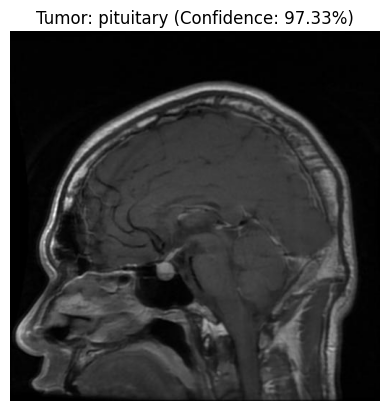

In [ ]:
image_path = '/content/drive/MyDrive/brain-tumor-mri-dataset/Testing/pituitary/Te-piTr_0006.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)